# Klasifikacija vremenskih nizova pomoću prozora (windowing)

- sintetički primjer snimke akcelerometra za sjedenje, hodanje, trčanje

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

np.random.seed(42)

fs = 50  # 50 samples/second

classes = {
    0: "sitting",
    1: "walking",
    2: "running"
}

def generate_segment(activity, duration_sec, fs=50):
    n = duration_sec * fs
    t = np.arange(n) / fs

    if activity == 0:
        # sitting: almost flat, just small noise
        signal = 0.05 * np.random.randn(n)

    elif activity == 1:
        # walking: moderate periodic movement
        signal = 0.8 * np.sin(2 * np.pi * 2.0 * t)
        signal += 0.15 * np.random.randn(n)

    elif activity == 2:
        # running: faster and stronger periodic movement
        signal = 1.4 * np.sin(2 * np.pi * 3.5 * t)
        signal += 0.25 * np.random.randn(n)

    return signal


activity_sequence = [
    (0, 20),  # sitting, 20 sec
    (1, 25),  # walking, 25 sec
    (0, 15),
    (2, 20),  # running, 20 sec
    (1, 20),
    (2, 15),
    (0, 20)
]

signals = []
point_labels = []

for activity, duration in activity_sequence:
    segment = generate_segment(activity, duration, fs)
    signals.append(segment)
    point_labels.extend([activity] * len(segment))

signal = np.concatenate(signals)
point_labels = np.array(point_labels)

print(signal.shape)
print(point_labels.shape)

(6750,)
(6750,)


## Cijeli zapis

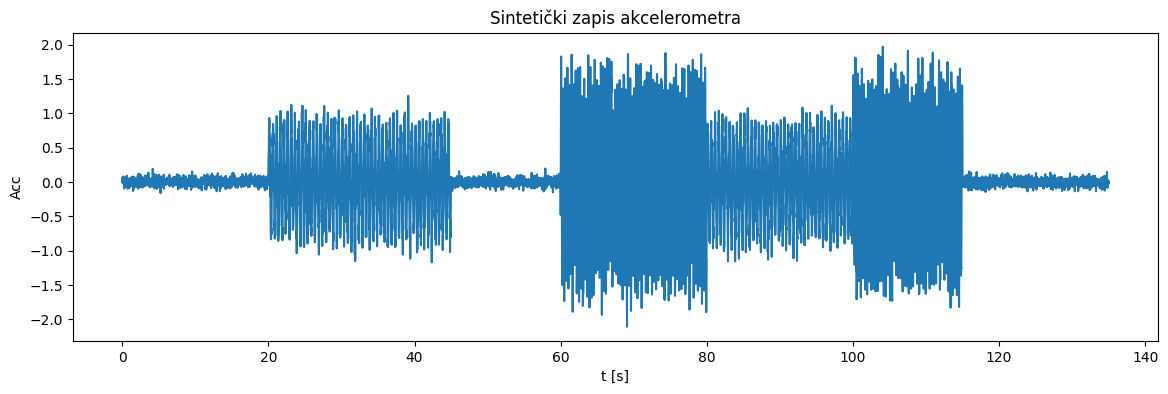

In [10]:
time = np.arange(len(signal)) / fs

plt.figure(figsize=(14, 4))
plt.plot(time, signal)
plt.xlabel("t [s]")
plt.ylabel("Acc")
plt.title("Sintetički zapis akcelerometra")
plt.show()

## Stvaranje prozora duljine 2s s preklapanjem (50%)

In [3]:
def create_windows(signal, point_labels, window_size, step_size):
    X = []
    y = []

    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size

        window = signal[start:end]
        labels_in_window = point_labels[start:end]

        # labela prozora = većinska labela
        values, counts = np.unique(labels_in_window, return_counts=True)
        label = values[np.argmax(counts)]

        X.append(window)
        y.append(label)

    return np.array(X), np.array(y)

window_size = 100   # 2s na 50 Hz
step_size = 50      # 50% preklapanje

X, y = create_windows(signal, point_labels, window_size, step_size)

print(X.shape)
print(y.shape)

(134, 100)
(134,)


In [8]:
X

array([[ 0.02483571, -0.00691322,  0.03238443, ...,  0.01305276,
         0.00025567, -0.01172936],
       [ 0.0162042 , -0.01925411, -0.0338461 , ..., -0.06602283,
         0.02609708,  0.01484923],
       [-0.07076854, -0.02103227, -0.01713573, ...,  0.00768626,
         0.00291044, -0.05714851],
       ...,
       [-0.00081116,  0.05784169,  0.01986985, ..., -0.0468296 ,
         0.05531158,  0.01003493],
       [-0.06447403,  0.00292247,  0.04563102, ...,  0.0563675 ,
        -0.05649249, -0.04119184],
       [ 0.01286267, -0.01722386, -0.0374708 , ...,  0.02591095,
        -0.02530945, -0.00897573]])

In [15]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

## Primjeri prozora

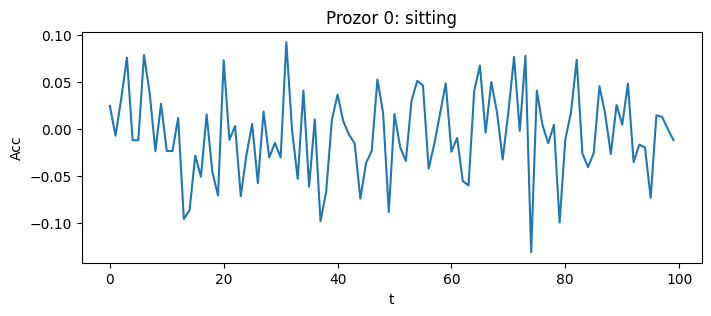

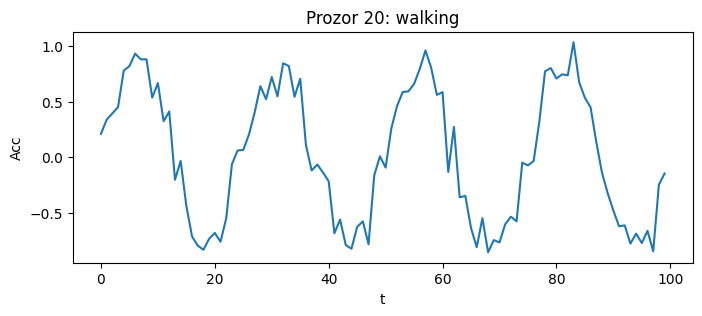

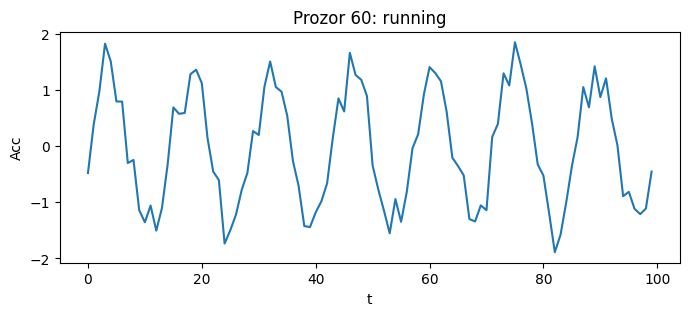

In [12]:
def plot_window(X, y, idx):
    plt.figure(figsize=(8, 3))
    plt.plot(X[idx])
    plt.title(f"Prozor {idx}: {classes[y[idx]]}")
    plt.xlabel("t") #ukupna duljina prozora je 2s
    plt.ylabel("Acc")
    plt.show()

for label in classes:
    idx = np.where(y == label)[0][0]
    plot_window(X, y, idx)

## Izlučivanje jednostavnih značajki

In [5]:
def extract_features(X):
    features = []

    for window in X:
        row = [
            window.mean(),
            window.std(),
            window.min(),
            window.max(),
            np.sum(window**2),              # energy
            np.mean(np.abs(window)),         # mean absolute value
            np.sum(np.diff(np.sign(window)) != 0)  # zero crossings
        ]

        features.append(row)

    return np.array(features)

X_feat = extract_features(X)

print(X_feat.shape)

(134, 7)


In [14]:
X_feat

array([[-5.19232587e-03,  4.51808088e-02, -1.30987255e-01,
         9.26139092e-02,  2.06826573e-01,  3.61401047e-02,
         5.50000000e+01],
       [-5.37667405e-04,  4.69205067e-02, -1.30987255e-01,
         1.23162106e-01,  2.20182304e-01,  3.69600819e-02,
         5.20000000e+01],
       [ 1.11522935e-03,  4.74444320e-02, -9.59385608e-02,
         1.36008458e-01,  2.25221787e-01,  3.78103293e-02,
         5.20000000e+01],
       [ 5.87165202e-03,  4.94151075e-02, -1.01257129e-01,
         1.92636575e-01,  2.47632915e-01,  3.91139252e-02,
         5.00000000e+01],
       [ 3.24481266e-03,  5.39423923e-02, -1.62063367e-01,
         1.92636575e-01,  2.92031050e-01,  4.27002627e-02,
         5.00000000e+01],
       [ 2.75113350e-04,  4.65383965e-02, -1.62063367e-01,
         1.06651669e-01,  2.16589804e-01,  3.71529341e-02,
         5.20000000e+01],
       [ 5.34200603e-03,  4.39834901e-02, -1.06194786e-01,
         1.09490147e-01,  1.96308443e-01,  3.53891571e-02,
         4.9000000

## Klasifikacija

              precision    recall  f1-score   support

     sitting       1.00      1.00      1.00        20
     walking       1.00      1.00      1.00         7
     running       1.00      1.00      1.00        14

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



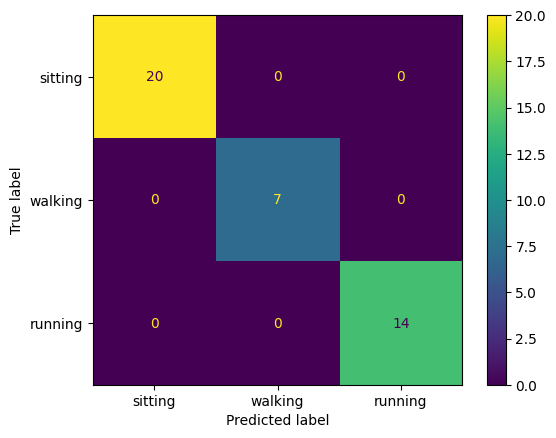

In [16]:
split_idx = int(0.7 * len(X_feat))

X_train = X_feat[:split_idx]
X_test = X_feat[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]


clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print(classification_report(
    y_test,
    pred,
    target_names=[classes[i] for i in sorted(classes)]
))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=[classes[i] for i in sorted(classes)]
)


plt.show()

In [7]:
print("Original signal shape:", signal.shape)
print("Windowed dataset shape:", X.shape)
print("Feature dataset shape:", X_feat.shape)

Original signal shape: (6750,)
Windowed dataset shape: (134, 100)
Feature dataset shape: (134, 7)
